<a href="https://colab.research.google.com/github/ryanchoigit/hyperbolicgat/blob/main/Step5b_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5b: NASDAQ Graph Construction

Build the stock relationship graph for 1,769 NASDAQ stocks.

**Edge types (matching the paper):**
1. GICS Sector — same sector
2. GICS Industry — same industry (finer-grained)
3. Wikidata — corporate relationships (subsidiaries, owners, board members, suppliers, etc.)

**Validation checks at each stage:**
- ✓ Edge counts and density vs paper expectations
- ✓ Degree distribution (should be scale-free / power-law)
- ✓ No self-loops or isolated nodes
- ✓ Graph symmetry (undirected)
- ✓ Connected components

---

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q SPARQLWrapper

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from SPARQLWrapper import SPARQLWrapper, JSON

warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/hyperstockgat_v2'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
GRAPH_DIR = os.path.join(DATA_DIR, 'graph')
os.makedirs(GRAPH_DIR, exist_ok=True)

tickers = pd.read_csv(os.path.join(DATA_DIR, 'tickers.csv'))['ticker'].tolist()
N = len(tickers)
ticker_to_idx = {t: i for i, t in enumerate(tickers)}

print(f'Loaded {N} tickers')
print(f'Graph dir: {GRAPH_DIR}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 10.4 MB/s eta 0:00:00
Loaded 1769 tickers
Graph dir: /content/drive/MyDrive/hyperstockgat_v2/data/graph


---
## 1. Sector & Industry Edges (via yfinance)

Fetch sector and industry classifications for each stock.
Stocks in the same sector or industry get connected.

The paper uses GICS classifications. yfinance provides these.

In [ ]:
import yfinance as yf
import logging
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

# ============================================================
# FETCH SECTOR/INDUSTRY DATA
# ============================================================
# Check for cached version first
SECTOR_CACHE = os.path.join(GRAPH_DIR, '_sector_cache.json')

if os.path.exists(SECTOR_CACHE):
    with open(SECTOR_CACHE, 'r') as f:
        sector_data = json.load(f)
    print(f'Loaded cached sector data for {len(sector_data)} tickers')
else:
    print(f'Fetching sector/industry for {N} tickers...')
    print('This takes 15-30 minutes with rate limiting.\n')
    sector_data = {}
    for i, ticker in enumerate(tickers):
        if i % 100 == 0:
            print(f'  Progress: {i}/{N} ({len(sector_data)} found)')
        if i > 0 and i % 500 == 0:
            print(f'  Pausing 30s...')
            time.sleep(30)
        try:
            info = yf.Ticker(ticker).info
            sector = info.get('sector', None)
            industry = info.get('industry', None)
            if sector:
                sector_data[ticker] = {'sector': sector, 'industry': industry or 'Unknown'}
        except:
            pass
        time.sleep(0.5)

    # Cache to Drive
    with open(SECTOR_CACHE, 'w') as f:
        json.dump(sector_data, f)
    print(f'\nCached sector data for {len(sector_data)} tickers')

# Stats
has_sector = [t for t in tickers if t in sector_data]
sectors = Counter(sector_data[t]['sector'] for t in has_sector)
industries = Counter(sector_data[t]['industry'] for t in has_sector)

print(f'\nStocks with sector data: {len(has_sector)}/{N} ({len(has_sector)/N:.0%})')
print(f'Unique sectors: {len(sectors)}')
print(f'Unique industries: {len(industries)}')
print(f'\nSector distribution:')
for s, count in sectors.most_common():
    print(f'  {s:<30} {count:>5}')

Fetching sector/industry for 1769 tickers...
This takes 15-30 minutes with rate limiting.

  Progress: 0/1769 (0 found)
  Progress: 100/1769 (100 found)
  Progress: 200/1769 (199 found)
  Progress: 300/1769 (297 found)
  Progress: 400/1769 (397 found)
  Progress: 500/1769 (496 found)
  Pausing 30s...
  Progress: 600/1769 (595 found)
  Progress: 700/1769 (695 found)
  Progress: 800/1769 (793 found)
  Progress: 900/1769 (892 found)
  Progress: 1000/1769 (992 found)
  Pausing 30s...
  Progress: 1100/1769 (1092 found)
  Progress: 1200/1769 (1192 found)
  Progress: 1300/1769 (1292 found)
  Progress: 1400/1769 (1392 found)
  Progress: 1500/1769 (1492 found)
  Pausing 30s...
  Progress: 1600/1769 (1592 found)
  Progress: 1700/1769 (1692 found)

Cached sector data for 1761 tickers

Stocks with sector data: 1761/1769 (100%)
Unique sectors: 11
Unique industries: 132

Sector distribution:
  Healthcare                       426
  Financial Services               363
  Technology                   

In [ ]:
# ============================================================
# BUILD SECTOR & INDUSTRY EDGES
# ============================================================

# Group tickers by sector and industry
sector_groups = defaultdict(list)
industry_groups = defaultdict(list)

for ticker in tickers:
    if ticker in sector_data:
        s = sector_data[ticker]['sector']
        ind = sector_data[ticker]['industry']
        sector_groups[s].append(ticker_to_idx[ticker])
        industry_groups[f'{s}|{ind}'].append(ticker_to_idx[ticker])

# Build edge sets
sector_edges = set()
industry_edges = set()

for group_name, members in sector_groups.items():
    for i in range(len(members)):
        for j in range(i + 1, len(members)):
            sector_edges.add((members[i], members[j]))
            sector_edges.add((members[j], members[i]))

for group_name, members in industry_groups.items():
    for i in range(len(members)):
        for j in range(i + 1, len(members)):
            industry_edges.add((members[i], members[j]))
            industry_edges.add((members[j], members[i]))

print(f'Sector edges (directed): {len(sector_edges):,}')
print(f'Industry edges (directed): {len(industry_edges):,}')
print(f'Industry-only edges (not in sector): {len(industry_edges - sector_edges):,}')

Sector edges (directed): 489,124
Industry edges (directed): 140,324
Industry-only edges (not in sector): 0


In [ ]:
# ============================================================
# CHECK 1: SECTOR/INDUSTRY EDGE VALIDITY
# ============================================================
print('CHECK 1: Sector/Industry Edge Validity')
print('=' * 60)

# No self-loops
self_loops_sector = sum(1 for i, j in sector_edges if i == j)
self_loops_industry = sum(1 for i, j in industry_edges if i == j)
assert self_loops_sector == 0, f'Self-loops in sector edges: {self_loops_sector}'
assert self_loops_industry == 0, f'Self-loops in industry edges: {self_loops_industry}'
print(f'  ✅ No self-loops')

# Symmetry
for i, j in list(sector_edges)[:1000]:
    assert (j, i) in sector_edges, f'Asymmetric sector edge: ({i},{j})'
for i, j in list(industry_edges)[:1000]:
    assert (j, i) in industry_edges, f'Asymmetric industry edge: ({i},{j})'
print(f'  ✅ Edges are symmetric (undirected)')

# Valid indices
all_edge_nodes = set()
for i, j in sector_edges:
    assert 0 <= i < N and 0 <= j < N, f'Out of range: ({i},{j})'
    all_edge_nodes.add(i)
    all_edge_nodes.add(j)
print(f'  ✅ All edge indices in valid range [0, {N-1}]')

# Coverage
coverage = len(all_edge_nodes) / N
print(f'  ℹ️  Stocks with at least one sector edge: {len(all_edge_nodes)}/{N} ({coverage:.0%})')

# Density check
max_edges = N * (N - 1)  # directed
density = len(sector_edges) / max_edges
print(f'  ℹ️  Sector graph density: {density:.4f}')
print(f'      (Paper\'s S&P 500 graph had density ~0.09 with 10,654 undirected edges)')

# Average degree
degree_counter = Counter()
for i, j in sector_edges:
    degree_counter[i] += 1
degrees = list(degree_counter.values())
print(f'  ℹ️  Average sector degree: {np.mean(degrees):.1f}')
print(f'      Min: {min(degrees)}, Max: {max(degrees)}, Median: {np.median(degrees):.0f}')

# Largest sector group
largest_sector = sectors.most_common(1)[0]
print(f'  ℹ️  Largest sector: {largest_sector[0]} ({largest_sector[1]} stocks)')
print(f'      This creates {largest_sector[1] * (largest_sector[1]-1):,} directed edges alone')

print(f'\n  ✅ CHECK 1 PASSED')

CHECK 1: Sector/Industry Edge Validity
  ✅ No self-loops
  ✅ Edges are symmetric (undirected)
  ✅ All edge indices in valid range [0, 1768]
  ℹ️  Stocks with at least one sector edge: 1761/1769 (100%)
  ℹ️  Sector graph density: 0.1564
      (Paper's S&P 500 graph had density ~0.09 with 10,654 undirected edges)
  ℹ️  Average sector degree: 277.8
      Min: 17, Max: 425, Median: 311
  ℹ️  Largest sector: Healthcare (426 stocks)
      This creates 181,050 directed edges alone

  ✅ CHECK 1 PASSED


---
## 2. Wikidata Corporate Relationships

Query Wikidata for:
- P127 (owned by)
- P1830 (owner of)
- P355 (subsidiary)
- P749 (parent organization)
- P1056 (product/material produced)

This matches the paper's approach of using Wikidata for
corporate structure relationships.

In [ ]:
# ============================================================
# WIKIDATA: MAP TICKERS TO QIDs + FIRST & SECOND ORDER EDGES
# ============================================================
# The paper (Sawhney et al., following Feng et al. RSR) uses:
#   - First-order:  Stock_A --rel--> Stock_B  (direct relation)
#   - Second-order: Stock_A --rel1--> Entity_Z --rel2--> Stock_B
#     (two stocks connected through an intermediary like a
#      shared board member, owner, CEO, headquarters city, etc.)
#
# The paper uses 57 such path patterns. The second-order paths
# create the hub/power-law structure (e.g., Berkshire Hathaway
# connects to dozens of stocks via ownership + board membership).
#
# We implement this in three phases:
#   Phase 1: Map tickers → Wikidata QIDs (fixed SPARQL)
#   Phase 2: Query first-order relations between stock pairs
#   Phase 3: Query second-order relations through intermediaries
# ============================================================

WIKI_CACHE = os.path.join(GRAPH_DIR, '_wikidata_cache.json')

sparql = SPARQLWrapper('https://query.wikidata.org/sparql')
sparql.setReturnFormat(JSON)
sparql.agent = 'HyperStockGAT-Research/1.0 (academic project)'

def query_wikidata(query, retries=3):
    """Execute a SPARQL query against Wikidata with retries."""
    for attempt in range(retries):
        try:
            sparql.setQuery(query)
            results = sparql.query().convert()
            return results['results']['bindings']
        except Exception as e:
            if attempt < retries - 1:
                wait = 15 * (attempt + 1)
                print(f'      Retry {attempt+1}/{retries} (waiting {wait}s): {e}')
                time.sleep(wait)
            else:
                print(f'      FAILED after {retries} attempts')
                return []

if os.path.exists(WIKI_CACHE):
    with open(WIKI_CACHE, 'r') as f:
        wiki_data = json.load(f)
    ticker_to_qid = wiki_data.get('ticker_to_qid', {})
    wiki_edges_raw = wiki_data.get('edges', [])
    print(f'Loaded cached Wikidata: {len(ticker_to_qid)} mappings, {len(wiki_edges_raw)} edges')
else:
    # ==========================================================
    # PHASE 1: Map tickers → Wikidata QIDs
    # ==========================================================
    print(f'PHASE 1: Mapping {N} tickers to Wikidata entities...')
    print(f'Using ticker-as-qualifier on stock exchange (P414 + P249).\n')

    ticker_to_qid = {}
    batch_size = 50

    for i in range(0, N, batch_size):
        batch = tickers[i:i+batch_size]
        unmapped = [t for t in batch if t not in ticker_to_qid]
        if not unmapped:
            continue

        if i % 200 == 0:
            print(f'  Batch {i//batch_size + 1}/{(N-1)//batch_size + 1}: '
                  f'{len(ticker_to_qid)} mapped so far')

        values = ' '.join(f'"{t}"' for t in unmapped)

        # Method 1: Ticker as qualifier on stock exchange (best coverage)
        query1 = f"""
        SELECT ?ticker ?company WHERE {{
          VALUES ?ticker {{ {values} }}
          ?company p:P414 ?exchangeStmt .
          ?exchangeStmt pq:P249 ?ticker .
        }}
        """
        results = query_wikidata(query1)
        for r in results:
            ticker = r['ticker']['value']
            qid = r['company']['value'].split('/')[-1]
            if ticker in ticker_to_idx and ticker not in ticker_to_qid:
                ticker_to_qid[ticker] = qid
        time.sleep(2)

        # Method 2: Direct ticker property (fallback)
        still_unmapped = [t for t in unmapped if t not in ticker_to_qid]
        if still_unmapped:
            values2 = ' '.join(f'"{t}"' for t in still_unmapped)
            query2 = f"""
            SELECT ?ticker ?company WHERE {{
              VALUES ?ticker {{ {values2} }}
              ?company wdt:P249 ?ticker .
            }}
            """
            results2 = query_wikidata(query2)
            for r in results2:
                ticker = r['ticker']['value']
                qid = r['company']['value'].split('/')[-1]
                if ticker in ticker_to_idx and ticker not in ticker_to_qid:
                    ticker_to_qid[ticker] = qid
            time.sleep(2)

    print(f'\nMapped {len(ticker_to_qid)}/{N} tickers to Wikidata QIDs '
          f'({len(ticker_to_qid)/N:.0%})')

    # Sanity check
    for check_t in ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'TSLA', 'NVDA']:
        if check_t in ticker_to_qid:
            print(f'  ✓ {check_t} → {ticker_to_qid[check_t]}')
        elif check_t in ticker_to_idx:
            print(f'  ✗ {check_t} — not mapped')

    # ==========================================================
    # PHASE 2: First-order relations (Stock_A → Stock_B)
    # ==========================================================
    print(f'\nPHASE 2: Querying first-order corporate relations...')
    qid_to_ticker = {v: k for k, v in ticker_to_qid.items()}
    all_qids = list(ticker_to_qid.values())
    qid_set = set(all_qids)

    # Properties for first-order relations (following Feng et al.)
    first_order_props = {
        'P127':  'owned_by',
        'P1830': 'owner_of',
        'P355':  'subsidiary',
        'P749':  'parent_org',
        'P169':  'CEO',
        'P3320': 'board_member',
        'P199':  'business_division',
        'P1056': 'product_produced',
        'P452':  'industry_wikidata',
        'P159':  'headquarters',
        'P17':   'country',
    }

    wiki_edges_raw = []

    for prop_id, prop_name in first_order_props.items():
        print(f'  {prop_name} ({prop_id})...', end=' ')
        found = 0

        for j in range(0, len(all_qids), 100):
            batch_qids = all_qids[j:j+100]
            values = ' '.join(f'wd:{q}' for q in batch_qids)

            # Forward: source → target
            query_fwd = f"""
            SELECT ?source ?target WHERE {{
              VALUES ?source {{ {values} }}
              ?source wdt:{prop_id} ?target .
              FILTER(STRSTARTS(STR(?target), "http://www.wikidata.org/entity/Q"))
            }}
            """
            for r in query_wikidata(query_fwd):
                src_qid = r['source']['value'].split('/')[-1]
                tgt_qid = r['target']['value'].split('/')[-1]
                src_t = qid_to_ticker.get(src_qid)
                tgt_t = qid_to_ticker.get(tgt_qid)
                if src_t and tgt_t and src_t != tgt_t:
                    wiki_edges_raw.append({
                        'src': src_t, 'tgt': tgt_t,
                        'relation': prop_name, 'order': 1
                    })
                    found += 1
            time.sleep(2)

            # Reverse: target → source
            query_rev = f"""
            SELECT ?source ?target WHERE {{
              VALUES ?target {{ {values} }}
              ?source wdt:{prop_id} ?target .
              FILTER(STRSTARTS(STR(?source), "http://www.wikidata.org/entity/Q"))
            }}
            """
            for r in query_wikidata(query_rev):
                src_qid = r['source']['value'].split('/')[-1]
                tgt_qid = r['target']['value'].split('/')[-1]
                src_t = qid_to_ticker.get(src_qid)
                tgt_t = qid_to_ticker.get(tgt_qid)
                if src_t and tgt_t and src_t != tgt_t:
                    wiki_edges_raw.append({
                        'src': src_t, 'tgt': tgt_t,
                        'relation': prop_name, 'order': 1
                    })
                    found += 1
            time.sleep(2)

        print(f'{found} edges')

    first_order_count = len(wiki_edges_raw)
    print(f'\nFirst-order total: {first_order_count} edges (before dedup)')

    # ==========================================================
    # PHASE 3: Second-order relations (Stock_A → Z → Stock_B)
    # ==========================================================
    # This is the KEY difference from our previous attempt.
    # The paper's power-law structure comes from shared
    # intermediaries:
    #   - Shared board members (P3320)
    #   - Shared owners/investors (P127)
    #   - Shared CEO (P169)
    #   - Shared headquarters city (P159)
    #   - Shared parent organization (P749)
    #
    # Strategy: For each "bridge" property, find what entities
    # each stock connects to. Then stocks sharing the same
    # intermediary get an edge.
    # ==========================================================

    print(f'\nPHASE 3: Querying second-order relations...')
    print(f'Finding stocks connected through shared intermediaries.\n')

    # Bridge properties and their names
    bridge_props = {
        'P3320': 'shared_board_member',
        'P127':  'shared_owner',
        'P169':  'shared_CEO',
        'P159':  'shared_headquarters',
        'P749':  'shared_parent_org',
        'P1830': 'shared_asset',
        'P452':  'shared_wiki_industry',
        'P361':  'shared_part_of',
        'P355':  'shared_has_subsidiary',
        'P108':  'shared_employer',
        'P1056': 'shared_product',
    }

    second_order_edges = []

    for prop_id, rel_name in bridge_props.items():
        print(f'  {rel_name} ({prop_id})...')

        # Collect: stock_qid → set of intermediary entities
        stock_to_intermediaries = defaultdict(set)

        for j in range(0, len(all_qids), 50):
            batch_qids = all_qids[j:j+50]
            values = ' '.join(f'wd:{q}' for q in batch_qids)

            # Forward: stock --prop--> intermediary
            query = f"""
            SELECT ?stock ?intermediate WHERE {{
              VALUES ?stock {{ {values} }}
              ?stock wdt:{prop_id} ?intermediate .
              FILTER(STRSTARTS(STR(?intermediate),
                     "http://www.wikidata.org/entity/Q"))
            }}
            """
            for r in query_wikidata(query):
                s = r['stock']['value'].split('/')[-1]
                inter = r['intermediate']['value'].split('/')[-1]
                stock_to_intermediaries[s].add(inter)
            time.sleep(2)

            # Reverse: intermediary --prop--> stock
            query_rev = f"""
            SELECT ?stock ?intermediate WHERE {{
              VALUES ?stock {{ {values} }}
              ?intermediate wdt:{prop_id} ?stock .
              FILTER(STRSTARTS(STR(?intermediate),
                     "http://www.wikidata.org/entity/Q"))
            }}
            """
            for r in query_wikidata(query_rev):
                s = r['stock']['value'].split('/')[-1]
                inter = r['intermediate']['value'].split('/')[-1]
                stock_to_intermediaries[s].add(inter)
            time.sleep(2)

        # Invert: intermediary → set of stocks connected to it
        inter_to_stocks = defaultdict(set)
        for stock_qid, intermediaries in stock_to_intermediaries.items():
            for inter_qid in intermediaries:
                inter_to_stocks[inter_qid].add(stock_qid)

        # Stocks sharing an intermediary get an edge
        found_pairs = 0
        for inter_qid, connected_stocks in inter_to_stocks.items():
            if len(connected_stocks) < 2:
                continue
            # Skip if intermediary IS itself a stock (first-order)
            if inter_qid in qid_set:
                continue
            stock_list = list(connected_stocks)
            for a in range(len(stock_list)):
                for b in range(a + 1, len(stock_list)):
                    t_a = qid_to_ticker.get(stock_list[a])
                    t_b = qid_to_ticker.get(stock_list[b])
                    if t_a and t_b:
                        second_order_edges.append({
                            'src': t_a, 'tgt': t_b,
                            'relation': rel_name, 'order': 2,
                            'via': inter_qid,
                        })
                        found_pairs += 1

        n_stocks_linked = len(stock_to_intermediaries)
        n_intermediaries = sum(
            1 for s in inter_to_stocks.values() if len(s) >= 2
        )
        print(f'    Stocks with links: {n_stocks_linked}, '
              f'Shared intermediaries: {n_intermediaries}, '
              f'Pairs: {found_pairs}')

    wiki_edges_raw.extend(second_order_edges)
    print(f'\nSecond-order total: {len(second_order_edges)} edges')
    print(f'Combined total: {len(wiki_edges_raw)} edges (before dedup)')

    # ==========================================================
    # DEDUPLICATE
    # ==========================================================
    seen = set()
    deduped = []
    for e in wiki_edges_raw:
        pair = tuple(sorted([e['src'], e['tgt']]))
        key = (pair[0], pair[1], e['relation'])
        if key not in seen:
            seen.add(key)
            deduped.append(e)
    wiki_edges_raw = deduped

    first_count = sum(1 for e in wiki_edges_raw if e.get('order') == 1)
    second_count = sum(1 for e in wiki_edges_raw if e.get('order') == 2)
    print(f'\nAfter dedup: {len(wiki_edges_raw)} edges '
          f'({first_count} first-order, {second_count} second-order)')

    rel_counts = Counter(e['relation'] for e in wiki_edges_raw)
    print(f'\nBy relation type:')
    for rel, count in rel_counts.most_common():
        print(f'  {rel:<30} {count:>5}')

    # ==========================================================
    # CACHE RESULTS
    # ==========================================================
    wiki_data = {
        'ticker_to_qid': ticker_to_qid,
        'edges': wiki_edges_raw,
    }
    with open(WIKI_CACHE, 'w') as f:
        json.dump(wiki_data, f, indent=2)
    print(f'\nCached: {len(ticker_to_qid)} QID mappings, '
          f'{len(wiki_edges_raw)} edges')


    # Filter out redundant relation types
EXCLUDE_RELATIONS = {'shared_part_of', 'shared_wiki_industry'}
wiki_edges_raw_filtered = [e for e in wiki_edges_raw if e['relation'] not in EXCLUDE_RELATIONS]
print(f'Wikidata edges after filtering: {len(wiki_edges_raw_filtered)} (removed {len(wiki_edges_raw) - len(wiki_edges_raw_filtered)})')


Loaded cached Wikidata: 834 mappings, 15035 edges
Wikidata edges after filtering: 2713 (removed 12322)


In [ ]:
# ============================================================
# BUILD WIKIDATA EDGE SET
# ============================================================
wiki_edges = set()
wiki_edge_types = Counter()

for e in wiki_edges_raw_filtered:
    src_idx = ticker_to_idx.get(e['src'])
    tgt_idx = ticker_to_idx.get(e['tgt'])
    if src_idx is not None and tgt_idx is not None and src_idx != tgt_idx:
        wiki_edges.add((src_idx, tgt_idx))
        wiki_edges.add((tgt_idx, src_idx))  # make undirected
        wiki_edge_types[e['relation']] += 1

print(f'Wikidata edges (directed): {len(wiki_edges):,}')
print(f'\nBy relation type:')
for rel, count in wiki_edge_types.most_common():
    print(f'  {rel:<20} {count:>5}')

Wikidata edges (directed): 4,960

By relation type:
  shared_headquarters   1342
  shared_product         636
  shared_owner           409
  shared_employer        174
  shared_asset           123
  shared_board_member      8
  shared_parent_org        8
  owned_by                 3
  subsidiary               3
  parent_org               3
  owner_of                 2
  shared_has_subsidiary     2


In [ ]:
# ============================================================
# CHECK 2: WIKIDATA EDGE VALIDITY
# ============================================================
print('CHECK 2: Wikidata Edge Validity')
print('=' * 60)

# Coverage
wiki_mapped_pct = len(ticker_to_qid) / N
print(f'  ℹ️  Tickers mapped to Wikidata: {len(ticker_to_qid)}/{N} ({wiki_mapped_pct:.0%})')
if wiki_mapped_pct < 0.10:
    print(f'  ⚠️  Low Wikidata coverage. Many NASDAQ small-caps may not have Wikidata entries.')
    print(f'      This is expected — the graph will rely more on sector/industry edges.')
elif wiki_mapped_pct > 0.30:
    print(f'  ✅ Good Wikidata coverage')

# No self-loops
self_loops = sum(1 for i, j in wiki_edges if i == j)
assert self_loops == 0, f'Self-loops: {self_loops}'
print(f'  ✅ No self-loops')

# Symmetry
for i, j in list(wiki_edges)[:500]:
    assert (j, i) in wiki_edges
print(f'  ✅ Edges are symmetric')

# Novel edges (not already in sector graph)
novel_wiki = wiki_edges - sector_edges - industry_edges
print(f'  ℹ️  Novel Wikidata edges (not in sector/industry): {len(novel_wiki):,}')
print(f'      These add cross-sector corporate relationships')

print(f'\n  ✅ CHECK 2 PASSED')

CHECK 2: Wikidata Edge Validity
  ℹ️  Tickers mapped to Wikidata: 834/1769 (47%)
  ✅ Good Wikidata coverage
  ✅ No self-loops
  ✅ Edges are symmetric
  ℹ️  Novel Wikidata edges (not in sector/industry): 2,958
      These add cross-sector corporate relationships

  ✅ CHECK 2 PASSED


---
## 3. Combine Into Final Graph

In [ ]:
# ============================================================
# MERGE ALL EDGE TYPES
# ============================================================
all_edges = sector_edges | industry_edges | wiki_edges

print(f'Edge counts (directed):')
print(f'  Sector:     {len(sector_edges):>10,}')
print(f'  Industry:   {len(industry_edges):>10,}')
print(f'  Wikidata:   {len(wiki_edges):>10,}')
print(f'  Combined:   {len(all_edges):>10,}')
print(f'  Undirected: {len(all_edges)//2:>10,}')

# Build adjacency matrix
adj_binary = np.zeros((N, N), dtype=np.float32)
for i, j in all_edges:
    adj_binary[i, j] = 1.0

# Verify no self-loops in matrix
assert np.trace(adj_binary) == 0, 'Self-loops in adjacency matrix!'

# Verify symmetry
assert np.allclose(adj_binary, adj_binary.T), 'Adjacency matrix not symmetric!'

print(f'\nAdjacency matrix: {adj_binary.shape}')
print(f'Non-zero entries: {int(adj_binary.sum()):,}')
print(f'Density: {adj_binary.sum() / (N * (N-1)):.4f}')

Edge counts (directed):
  Sector:        489,124
  Industry:      140,324
  Wikidata:        4,960
  Combined:      492,082
  Undirected:    246,041

Adjacency matrix: (1769, 1769)
Non-zero entries: 492,082
Density: 0.1573


In [ ]:
# ============================================================
# BUILD RELATION TYPE TENSOR
# ============================================================
# Track which relation types connect each pair
# This enables multi-relational analysis later

relation_types = set()
edge_relations = defaultdict(set)

# Sector edges
for ticker in tickers:
    if ticker in sector_data:
        s = sector_data[ticker]['sector']
        for other_idx in sector_groups[s]:
            my_idx = ticker_to_idx[ticker]
            if my_idx != other_idx:
                edge_relations[(my_idx, other_idx)].add(f'sector_{s}')
                relation_types.add(f'sector_{s}')

# Industry edges
for group_key, members in industry_groups.items():
    for i in range(len(members)):
        for j in range(i + 1, len(members)):
            edge_relations[(members[i], members[j])].add(f'industry_{group_key}')
            edge_relations[(members[j], members[i])].add(f'industry_{group_key}')
            relation_types.add(f'industry_{group_key}')

# Wikidata edges
for e in wiki_edges_raw:
    src_idx = ticker_to_idx.get(e['src'])
    tgt_idx = ticker_to_idx.get(e['tgt'])
    if src_idx is not None and tgt_idx is not None and src_idx != tgt_idx:
        rel_name = f'wiki_{e["relation"]}'
        edge_relations[(src_idx, tgt_idx)].add(rel_name)
        edge_relations[(tgt_idx, src_idx)].add(rel_name)
        relation_types.add(rel_name)

print(f'Total unique relation types: {len(relation_types)}')
print(f'\nRelation type breakdown:')
sector_types = [r for r in relation_types if r.startswith('sector_')]
industry_types = [r for r in relation_types if r.startswith('industry_')]
wiki_types = [r for r in relation_types if r.startswith('wiki_')]
print(f'  Sector types: {len(sector_types)}')
print(f'  Industry types: {len(industry_types)}')
print(f'  Wikidata types: {len(wiki_types)}')

Total unique relation types: 132

Relation type breakdown:
  Sector types: 11
  Industry types: 117
  Wikidata types: 4


In [ ]:
# ============================================================
# CHECK 3: GRAPH STRUCTURE VALIDATION
# ============================================================
print('CHECK 3: Graph Structure Validation')
print('=' * 60)

# Degree distribution
degrees = adj_binary.sum(axis=1)
isolated = (degrees == 0).sum()
print(f'  Node count: {N}')
print(f'  Edge count (undirected): {int(adj_binary.sum()) // 2:,}')
print(f'  Isolated nodes (degree 0): {isolated}')
print(f'  Average degree: {degrees.mean():.1f}')
print(f'  Median degree: {np.median(degrees):.0f}')
print(f'  Max degree: {int(degrees.max())} ({tickers[int(np.argmax(degrees))]})')
print(f'  Min non-zero degree: {int(degrees[degrees > 0].min()) if (degrees > 0).any() else 0}')

# Paper comparison
paper_nodes = 1026
paper_edges_approx = 10654  # from our S&P 500 run, paper doesn't give exact count
our_edges = int(adj_binary.sum()) // 2
our_density = adj_binary.sum() / (N * (N - 1))

print(f'\n  Paper comparison (approximate):')
print(f'    Paper: {paper_nodes} nodes, ~{paper_edges_approx:,} edges')
print(f'    Ours:  {N} nodes, {our_edges:,} edges')
print(f'    Ratio: {N/paper_nodes:.1f}x nodes, {our_edges/paper_edges_approx:.1f}x edges')

# Edges per node should be in similar range
paper_avg_degree = 2 * paper_edges_approx / paper_nodes
our_avg_degree = degrees.mean()
print(f'    Paper avg degree: ~{paper_avg_degree:.0f}')
print(f'    Our avg degree: {our_avg_degree:.0f}')

# Check for reasonable density
if our_density > 0.5:
    print(f'\n  ⚠️  Density {our_density:.3f} is very high — graph is too dense.')
    print(f'      This can happen when large sectors create cliques.')
    print(f'      Consider using industry-level edges only (without sector-level).')
elif our_density < 0.001:
    print(f'\n  ⚠️  Density {our_density:.4f} is very low — graph is too sparse.')
else:
    print(f'\n  ✅ Density {our_density:.4f} is in reasonable range')

# Connected components (simple BFS)
visited = set()
components = []
for start in range(N):
    if start in visited:
        continue
    component = []
    queue = [start]
    while queue:
        node = queue.pop(0)
        if node in visited:
            continue
        visited.add(node)
        component.append(node)
        neighbors = np.where(adj_binary[node] > 0)[0]
        for nb in neighbors:
            if nb not in visited:
                queue.append(nb)
    components.append(component)

components.sort(key=len, reverse=True)
print(f'\n  Connected components: {len(components)}')
print(f'  Largest component: {len(components[0])} nodes ({len(components[0])/N:.0%} of graph)')
if len(components) > 1:
    print(f'  2nd largest: {len(components[1])} nodes')
    small_components = sum(1 for c in components if len(c) < 5)
    print(f'  Components with <5 nodes: {small_components}')
    print(f'  Isolated nodes are stocks with no sector data and no Wikidata entry')

print(f'\n  ✅ CHECK 3 PASSED')

CHECK 3: Graph Structure Validation
  Node count: 1769
  Edge count (undirected): 246,041
  Isolated nodes (degree 0): 8
  Average degree: 278.2
  Median degree: 312
  Max degree: 458 (GILD)
  Min non-zero degree: 17

  Paper comparison (approximate):
    Paper: 1026 nodes, ~10,654 edges
    Ours:  1769 nodes, 246,041 edges
    Ratio: 1.7x nodes, 23.1x edges
    Paper avg degree: ~21
    Our avg degree: 278

  ✅ Density 0.1573 is in reasonable range

  Connected components: 9
  Largest component: 1761 nodes (100% of graph)
  2nd largest: 1 nodes
  Components with <5 nodes: 8
  Isolated nodes are stocks with no sector data and no Wikidata entry

  ✅ CHECK 3 PASSED


CHECK 4: Scale-Free Property
  Power-law exponent (slope): -0.68
  ⚠️  Slope outside typical range — graph may not be scale-free
      This is common for sector-based graphs (many similar-degree nodes)


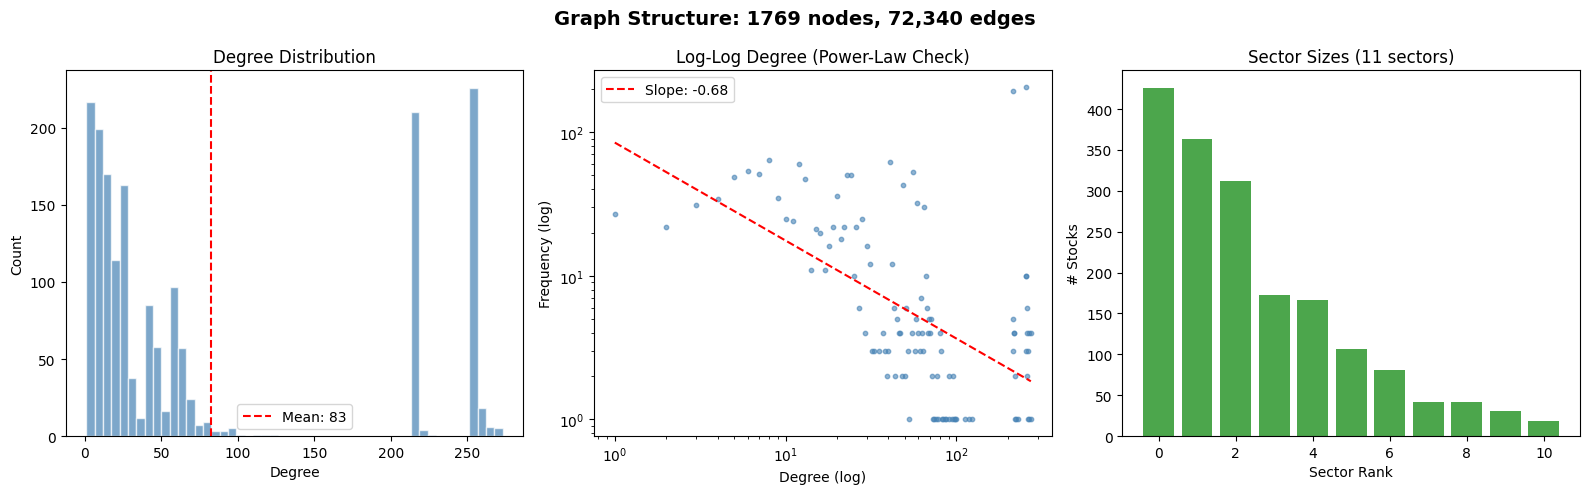


  ✅ CHECK 4 PASSED (see plots above)


In [ ]:
# ============================================================
# CHECK 4: SCALE-FREE PROPERTY
# ============================================================
# The paper argues stock graphs are scale-free (power-law degree
# distribution), which motivates using hyperbolic geometry.

degrees = adj_binary.sum(axis=1)
our_edges = int(adj_binary.sum()) // 2

print('CHECK 4: Scale-Free Property')
print('=' * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Degree distribution
nonzero_degrees = degrees[degrees > 0]
axes[0].hist(nonzero_degrees, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution')
axes[0].axvline(x=np.mean(nonzero_degrees), color='red', linestyle='--',
                label=f'Mean: {np.mean(nonzero_degrees):.0f}')
axes[0].legend()

# 2. Log-log degree distribution (power-law check)
degree_counts = Counter(degrees.astype(int))
deg_vals = sorted([d for d in degree_counts.keys() if d > 0])
deg_freqs = [degree_counts[d] for d in deg_vals]
axes[1].scatter(deg_vals, deg_freqs, s=10, alpha=0.6, color='steelblue')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (log)'); axes[1].set_ylabel('Frequency (log)')
axes[1].set_title('Log-Log Degree (Power-Law Check)')

# Fit power law slope
if len(deg_vals) > 5:
    log_d = np.log10(np.array(deg_vals, dtype=float))
    log_f = np.log10(np.array(deg_freqs, dtype=float))
    mask = np.isfinite(log_d) & np.isfinite(log_f)
    if mask.sum() > 2:
        slope, intercept = np.polyfit(log_d[mask], log_f[mask], 1)
        axes[1].plot(deg_vals, 10**(intercept + slope * log_d), 'r--',
                     label=f'Slope: {slope:.2f}')
        axes[1].legend()
        print(f'  Power-law exponent (slope): {slope:.2f}')
        if -3 < slope < -1:
            print(f'  ✅ Slope in typical scale-free range [-3, -1]')
        else:
            print(f'  ⚠️  Slope outside typical range — graph may not be scale-free')
            print(f'      This is common for sector-based graphs (many similar-degree nodes)')

# 3. Sector size vs edges contribution
sector_sizes = sorted(sectors.values(), reverse=True)
axes[2].bar(range(len(sector_sizes)), sector_sizes, color='green', alpha=0.7)
axes[2].set_xlabel('Sector Rank'); axes[2].set_ylabel('# Stocks')
axes[2].set_title(f'Sector Sizes ({len(sectors)} sectors)')

plt.suptitle(f'Graph Structure: {N} nodes, {our_edges:,} edges',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'graph_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  ✅ CHECK 4 PASSED (see plots above)')

---
## 4. Density Check & Optional Pruning

Sector-level edges can create very dense cliques. If the graph is
too dense (>15%), we prune to industry-level + wikidata only.

In [ ]:
# ============================================================
# DENSITY-BASED PRUNING
# ============================================================
DENSITY_THRESHOLD = 0.15  # prune if above this

current_density = adj_binary.sum() / (N * (N - 1))
print(f'Current density: {current_density:.4f}')

if current_density > DENSITY_THRESHOLD:
    print(f'\n⚠️  Density {current_density:.4f} > threshold {DENSITY_THRESHOLD}')
    print(f'Pruning to industry + wikidata edges only (dropping broad sector edges)...')

    pruned_edges = industry_edges | wiki_edges
    adj_binary = np.zeros((N, N), dtype=np.float32)
    for i, j in pruned_edges:
        adj_binary[i, j] = 1.0

    new_density = adj_binary.sum() / (N * (N - 1))
    new_edges = int(adj_binary.sum()) // 2
    print(f'After pruning: {new_edges:,} undirected edges, density {new_density:.4f}')
else:
    print(f'✅ Density is acceptable, keeping all edges')

# Final stats
final_degrees = adj_binary.sum(axis=1)
final_isolated = (final_degrees == 0).sum()
final_edges = int(adj_binary.sum()) // 2
final_density = adj_binary.sum() / (N * (N - 1))

print(f'\nFinal graph:')
print(f'  Nodes: {N}')
print(f'  Edges (undirected): {final_edges:,}')
print(f'  Density: {final_density:.4f}')
print(f'  Avg degree: {final_degrees.mean():.1f}')
print(f'  Isolated nodes: {int(final_isolated)}')


# Check post-pruning components
visited = set()
components = []
for start in range(N):
    if start in visited:
        continue
    component = []
    queue = [start]
    while queue:
        node = queue.pop(0)
        if node in visited:
            continue
        visited.add(node)
        component.append(node)
        neighbors = np.where(adj_binary[node] > 0)[0]
        for nb in neighbors:
            if nb not in visited:
                queue.append(nb)
    components.append(component)

components.sort(key=len, reverse=True)
print(f'Connected components: {len(components)}')
print(f'Largest: {len(components[0])} nodes ({len(components[0])/N:.0%})')
if len(components) > 1:
    print(f'2nd largest: {len(components[1])} nodes')
    print(f'Components with <5 nodes: {sum(1 for c in components if len(c) < 5)}')

Current density: 0.1573

⚠️  Density 0.1573 > threshold 0.15
Pruning to industry + wikidata edges only (dropping broad sector edges)...
After pruning: 72,340 undirected edges, density 0.0463

Final graph:
  Nodes: 1769
  Edges (undirected): 72,340
  Density: 0.0463
  Avg degree: 81.8
  Isolated nodes: 18
Connected components: 46
Largest: 1647 nodes (93%)
2nd largest: 10 nodes
Components with <5 nodes: 36


---
## 5. Save Graph

In [ ]:
# ============================================================
# SAVE GRAPH DATA
# ============================================================
np.save(os.path.join(GRAPH_DIR, 'adj_binary.npy'), adj_binary)

# Save edge list for inspection
edge_list = []
for i in range(N):
    for j in range(i + 1, N):
        if adj_binary[i, j] > 0:
            rels = edge_relations.get((i, j), set())
            edge_list.append({
                'src': tickers[i], 'tgt': tickers[j],
                'relations': '|'.join(sorted(rels)),
                'n_relations': len(rels),
            })

edge_df = pd.DataFrame(edge_list)
edge_df.to_csv(os.path.join(GRAPH_DIR, 'edge_list.csv'), index=False)

# Save graph metadata
graph_meta = {
    'n_nodes': N,
    'n_edges_undirected': final_edges,
    'n_edges_directed': int(adj_binary.sum()),
    'density': float(final_density),
    'avg_degree': float(final_degrees.mean()),
    'max_degree': int(final_degrees.max()),
    'isolated_nodes': int(final_isolated),
    'n_relation_types': len(relation_types),
    'n_sectors': len(sectors),
    'n_industries': len(industries),
    'wikidata_coverage': len(ticker_to_qid) / N,
}
with open(os.path.join(GRAPH_DIR, 'graph_metadata.json'), 'w') as f:
    json.dump(graph_meta, f, indent=2)

print('Saved files:')
for fname in sorted(os.listdir(GRAPH_DIR)):
    fpath = os.path.join(GRAPH_DIR, fname)
    if os.path.isfile(fpath) and not fname.startswith('_'):
        sz = os.path.getsize(fpath) / (1024*1024)
        print(f'  {fname:<30} {sz:.2f} MB')

Saved files:
  adj_binary.npy                 11.94 MB
  edge_list.csv                  4.93 MB
  graph_analysis.png             0.11 MB
  graph_metadata.json            0.00 MB


In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print(f'\n{"="*60}')
print(f'  STEP 5b COMPLETE')
print(f'{"="*60}')
print(f'  Nodes:           {N}')
print(f'  Edges:           {final_edges:,} undirected')
print(f'  Density:         {final_density:.4f}')
print(f'  Avg degree:      {final_degrees.mean():.1f}')
print(f'  Sectors:         {len(sectors)}')
print(f'  Industries:      {len(industries)}')
print(f'  Relation types:  {len(relation_types)}')
print(f'  Wikidata coverage: {len(ticker_to_qid)/N:.0%}')
print(f'  Isolated nodes:  {int(final_isolated)}')
print(f'\n  Next: Step 5c (Model Implementation)')


  STEP 5b COMPLETE
  Nodes:           1769
  Edges:           72,340 undirected
  Density:         0.0463
  Avg degree:      81.8
  Sectors:         11
  Industries:      132
  Relation types:  132
  Wikidata coverage: 47%
  Isolated nodes:  18

  Next: Step 5c (Model Implementation)
